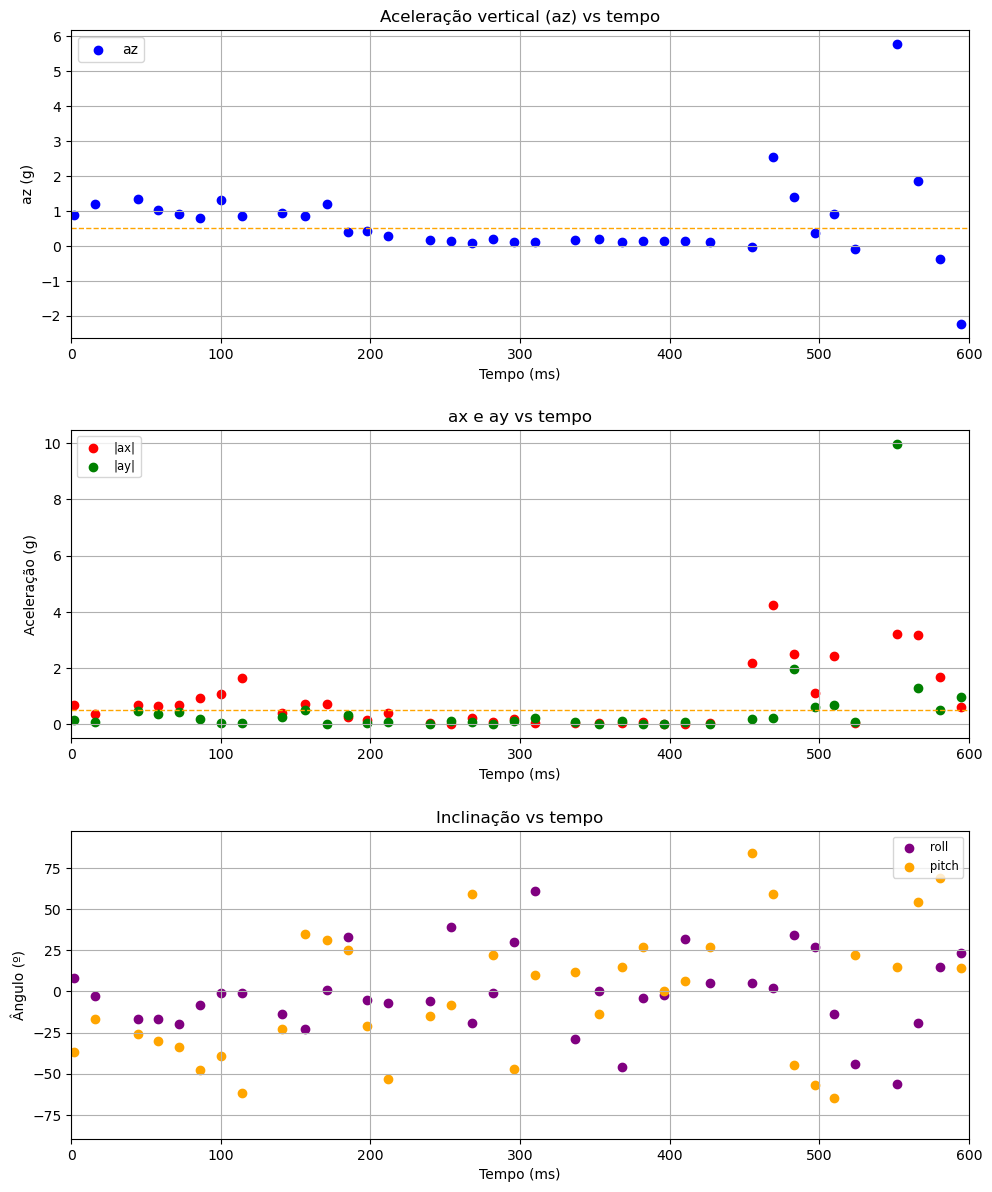

<Figure size 400x200 with 0 Axes>

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import math
g = 9.81
# Load the data
file_path = r"C:\Users\tiago\OneDrive\0 LEF\3º ano\2S\Projeto Integrador\Ax Ay Az roll pitch time\queda_2,5x_sem_tumble.txt"
ax, ay, az, roll, pitch, col, time = np.loadtxt(file_path, unpack=True)

# Combine into one array: [time, ax, ay, az, roll, pitch, col]
data = np.column_stack((time, ax, ay, az, roll, pitch, col))

# Find breakpoints where time resets
breaks = [0]
for i in range(1, len(time)):
    if time[i] < time[i - 1]:
        breaks.append(i)
breaks.append(len(time))

# Filter segments where either ax or ay exceed |3000|
valid_segments = []
for seg_num in range(len(breaks) - 1):
    start, end = breaks[seg_num], breaks[seg_num + 1]
    segment = data[start:end]
    ax_seg = segment[:, 1]
    ay_seg = segment[:, 2]
    
    if np.max(np.abs(ax_seg)) >= 3000 or np.max(np.abs(ay_seg)) >= 3000:
        valid_segments.append((start, end))

# Prepare subplots (3 rows for each segment: az, ax&ay, roll&pitch)
num_valid = len(valid_segments)
cols = 1
rows = num_valid * 3  # 3 plots per segment vertically stacked

fig, axes = plt.subplots(rows, cols, figsize=(10, 4 * rows), squeeze=False)

for idx, (start, end) in enumerate(valid_segments):
    segment = data[start:end]
    
    t = segment[:, 0] - 8300
    ax_seg = segment[:, 1]
    ay_seg = segment[:, 2]
    az_seg = segment[:, 3]
    roll_seg = segment[:, 4]
    pitch_seg = segment[:, 5]
    col_seg = segment[:, 6]
    
    base_row = idx * 3
    
    # Plot az vs time
    plt.figure(figsize = (4, 2))
   # Plot az vs time
    ax_az = axes[base_row, 0]
    ax_az.scatter(t, az_seg/(100*g), label='az', color='blue')
    ax_az.axhline(0.5, color='orange', linestyle='--', linewidth=1)  # Horizontal line at 0.5g
    ax_az.set_title(f'Aceleração vertical (az) vs tempo')
    ax_az.set_xlabel('Tempo (ms)')
    ax_az.set_ylabel('az (g)')
    ax_az.set_xlim(0, 600)
    ax_az.legend(loc='upper left')
    ax_az.grid(True)
    
    # Plot ax and ay vs time
    ax_axay = axes[base_row + 1, 0]
    ax_axay.scatter(t, np.abs(ax_seg/(100*g)), label='|ax|', color='red')
    ax_axay.scatter(t, np.abs(ay_seg/(100*g)), label='|ay|', color='green')
    ax_axay.axhline(0.5, color='orange', linestyle='--', linewidth=1)  # Horizontal line at 0.5g
    ax_axay.set_title(f'ax e ay vs tempo')
    ax_axay.set_xlabel('Tempo (ms)')
    ax_axay.set_ylabel('Aceleração (g)')
    ax_axay.legend(fontsize='small', loc='upper left')
    ax_axay.set_xlim(0, 600)
    ax_axay.grid(True)


    # Plot roll and pitch vs time
    ax_rollpitch = axes[base_row + 2, 0]
    ax_rollpitch.scatter(t, roll_seg, label='roll', color='purple')
    ax_rollpitch.scatter(t, pitch_seg, label='pitch', color='orange')
    ax_rollpitch.set_title(f'Inclinação vs tempo')
    ax_rollpitch.set_xlabel('Tempo (ms)')
    ax_rollpitch.set_ylabel('Ângulo (º)')
    ax_rollpitch.legend(fontsize='small')
    ax_rollpitch.set_xlim(0, 600)
    ax_rollpitch.grid(True)

fig.tight_layout(pad=1.0)  # pad controls padding around the figure
fig.subplots_adjust(hspace=0.3)  # hspace controls vertical spacing between subplots
plt.show()


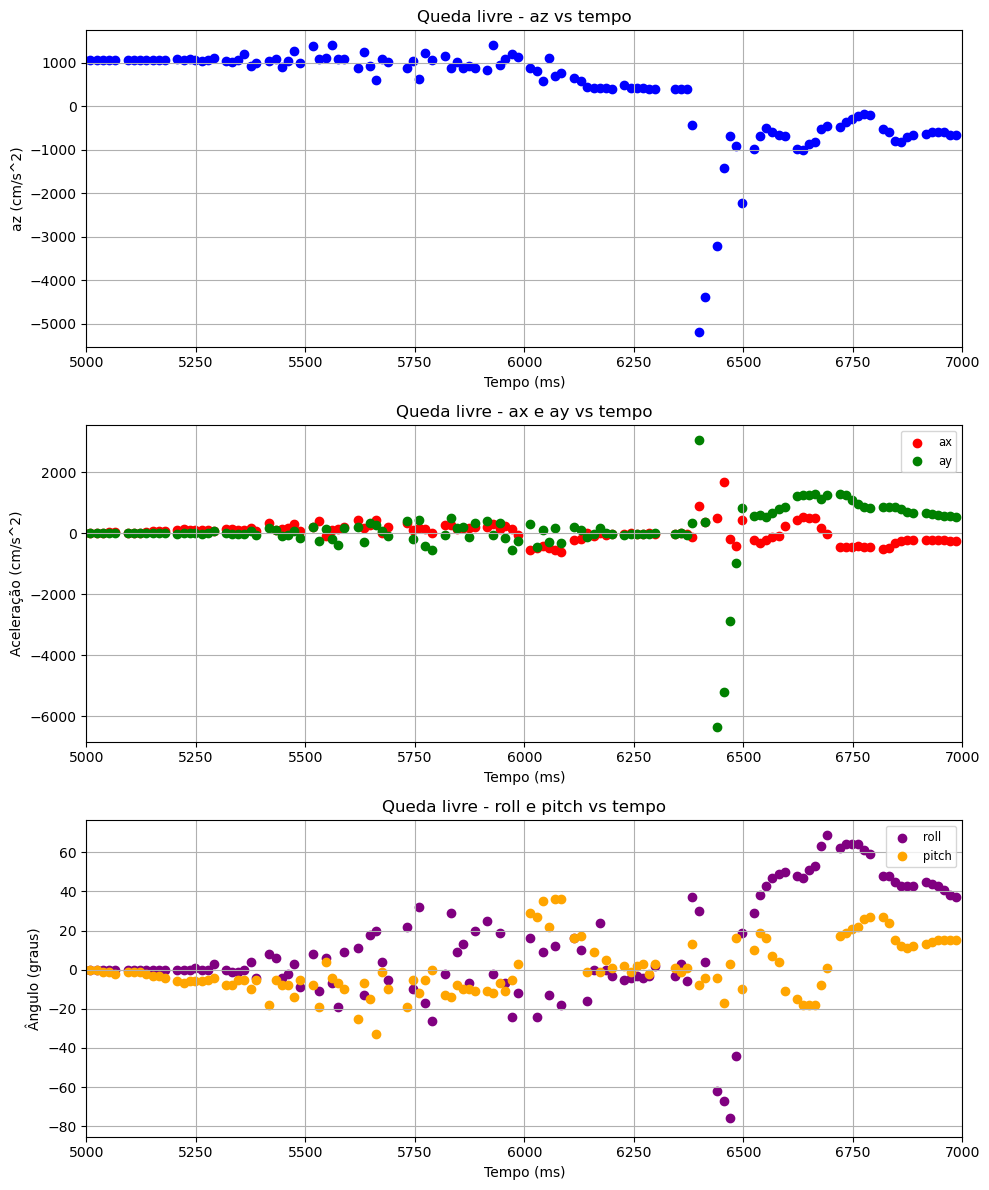

In [40]:
import numpy as np
import matplotlib.pyplot as plt
import math

# Load the data
file_path = r"C:\Users\tiago\OneDrive\0 LEF\3º ano\2S\Projeto Integrador\Ax Ay Az roll pitch time\queda_maior_2,5x_1.txt"
ax, ay, az, roll, pitch, col, time = np.loadtxt(file_path, unpack=True)

# Combine into one array: [time, ax, ay, az, roll, pitch, col]
data = np.column_stack((time, ax, ay, az, roll, pitch, col))

# Find breakpoints where time resets
breaks = [0]
for i in range(1, len(time)):
    if time[i] < time[i - 1]:
        breaks.append(i)
breaks.append(len(time))

# Filter segments where either ax or ay exceed |3000|
valid_segments = []
for seg_num in range(len(breaks) - 1):
    start, end = breaks[seg_num], breaks[seg_num + 1]
    segment = data[start:end]
    ax_seg = segment[:, 1]
    ay_seg = segment[:, 2]
    
    if np.max(np.abs(ax_seg)) >= 3000 or np.max(np.abs(ay_seg)) >= 3000:
        valid_segments.append((start, end))

# Prepare subplots (3 rows for each segment: az, ax&ay, roll&pitch)
num_valid = len(valid_segments)
cols = 1
rows = num_valid * 3  # 3 plots per segment vertically stacked

fig, axes = plt.subplots(rows, cols, figsize=(10, 4 * rows), squeeze=False)

for idx, (start, end) in enumerate(valid_segments):
    segment = data[start:end]
    
    t = segment[:, 0]
    ax_seg = segment[:, 1]
    ay_seg = segment[:, 2]
    az_seg = segment[:, 3]
    roll_seg = segment[:, 4]
    pitch_seg = segment[:, 5]
    col_seg = segment[:, 6]

    base_row = idx * 3
    
    # Plot az vs time
    ax_az = axes[base_row, 0]
    ax_az.scatter(t, az_seg, color='blue')
    ax_az.set_title(f'Queda livre - az vs tempo')
    ax_az.set_xlabel('Tempo (ms)')
    ax_az.set_ylabel('az (cm/s^2)')
    ax_az.set_xlim(5000, 7000)
    ax_az.grid(True)

    # Plot ax and ay vs time
    ax_axay = axes[base_row + 1, 0]
    ax_axay.scatter(t, ax_seg, label='ax', color='red')
    ax_axay.scatter(t, ay_seg, label='ay', color='green')
    ax_axay.set_title(f'Queda livre - ax e ay vs tempo')
    ax_axay.set_xlabel('Tempo (ms)')
    ax_axay.set_ylabel('Aceleração (cm/s^2)')
    ax_axay.legend(fontsize='small')
    ax_axay.set_xlim(5000, 7000)
    ax_axay.grid(True)

    # Plot roll and pitch vs time
    ax_rollpitch = axes[base_row + 2, 0]
    ax_rollpitch.scatter(t, roll_seg, label='roll', color='purple')
    ax_rollpitch.scatter(t, pitch_seg, label='pitch', color='orange')
    ax_rollpitch.set_title(f'Queda livre - roll e pitch vs tempo')
    ax_rollpitch.set_xlabel('Tempo (ms)')
    ax_rollpitch.set_ylabel('Ângulo (graus)')
    ax_rollpitch.legend(fontsize='small')
    ax_rollpitch.set_xlim(5000, 7000)
    ax_rollpitch.grid(True)

plt.tight_layout()
plt.show()
